# Análise Exploratória de Dados — Recursos Humanos

## O que os dados contam sobre a estrutura de RH?

 Este notebook parte de duas consultas SQL para investigar a estrutura de Recursos Humanos a partir dos dados de salários, cargos, departamentos e localização dos funcionários.

### Dados utilizados

- `query_01.csv` — salários por departamento e cargo
- `query_02.csv` — funcionários por região e localização

A proposta é observar os dados, identificar o que eles mostram e entender quais perguntas podem surgir a partir dessa análise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_query1 = pd.read_csv("../data/query_01.csv")
df_query2 = pd.read_csv("../data/query_02.csv")

### Estrutura dos dados

In [3]:
print("QUERY 1")
print("Shape:", df_query1.shape)
print("\nColunas:")
print(df_query1.columns.tolist())

print("\nQUERY 2")
print("Shape:", df_query2.shape)
print("\nColunas:")
print(df_query2.columns.tolist())

QUERY 1
Shape: (107, 6)

Colunas:
['EMPLOYEE_ID', 'FIRST_NAME', 'LAST_NAME', 'SALARY', 'DEPARTMENT_NAME', 'JOB_TITLE']

QUERY 2
Shape: (107, 9)

Colunas:
['EMPLOYEE_ID', 'FIRST_NAME', 'LAST_NAME', 'SALARY', 'DEPARTMENT_NAME', 'JOB_TITLE', 'CITY', 'COUNTRY_NAME', 'REGION_NAME']


### Tipos das variáveis

In [4]:
print("TIPOS — QUERY 1")
print(df_query1.dtypes)

print("\nTIPOS — QUERY 2")
print(df_query2.dtypes)

TIPOS — QUERY 1
EMPLOYEE_ID        int64
FIRST_NAME           str
LAST_NAME            str
SALARY             int64
DEPARTMENT_NAME      str
JOB_TITLE            str
dtype: object

TIPOS — QUERY 2
EMPLOYEE_ID        int64
FIRST_NAME           str
LAST_NAME            str
SALARY             int64
DEPARTMENT_NAME      str
JOB_TITLE            str
CITY                 str
COUNTRY_NAME         str
REGION_NAME          str
dtype: object


### Primeiro contato com os registros

In [5]:
print("PRIMEIROS REGISTROS — QUERY 1")
display(df_query1.head())

print("\nPRIMEIROS REGISTROS — QUERY 2")
display(df_query2.head())

PRIMEIROS REGISTROS — QUERY 1


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE
0,200,Jennifer,Whalen,4400,Administration,Administration Assistant
1,201,Michael,Martinez,13000,Marketing,Marketing Manager
2,202,Pat,Davis,6000,Marketing,Marketing Representative
3,114,Den,Li,11000,Purchasing,Purchasing Manager
4,115,Alexander,Khoo,3100,Purchasing,Purchasing Clerk



PRIMEIROS REGISTROS — QUERY 2


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE,CITY,COUNTRY_NAME,REGION_NAME
0,103,Alexander,James,9000,IT,Programmer,Southlake,United States of America,Americas
1,104,Bruce,Miller,6000,IT,Programmer,Southlake,United States of America,Americas
2,105,David,Williams,4800,IT,Programmer,Southlake,United States of America,Americas
3,106,Valli,Jackson,4800,IT,Programmer,Southlake,United States of America,Americas
4,107,Diana,Nguyen,4200,IT,Programmer,Southlake,United States of America,Americas


In [6]:
print("ÚLTIMOS REGISTROS — QUERY 1")
display(df_query1.tail())

print("\nÚLTIMOS REGISTROS — QUERY 2")
display(df_query2.tail())

ÚLTIMOS REGISTROS — QUERY 1


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE
102,112,Jose Manuel,Urman,7800,Finance,Accountant
103,113,Luis,Popp,6900,Finance,Accountant
104,205,Shelley,Higgins,12008,Accounting,Accounting Manager
105,206,William,Gietz,8300,Accounting,Public Accountant
106,178,Kimberely,Grant,7000,NaN,Sales Representative



ÚLTIMOS REGISTROS — QUERY 2


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE,CITY,COUNTRY_NAME,REGION_NAME
102,176,Jonathon,Taylor,8600,Sales,Sales Representative,Oxford,United Kingdom of Great Britain and Northern I...,Europe
103,177,Jack,Livingston,8400,Sales,Sales Representative,Oxford,United Kingdom of Great Britain and Northern I...,Europe
104,179,Charles,Johnson,6200,Sales,Sales Representative,Oxford,United Kingdom of Great Britain and Northern I...,Europe
105,204,Hermann,Brown,10000,Public Relations,Public Relations Representative,Munich,Germany,Europe
106,178,Kimberely,Grant,7000,NaN,Sales Representative,NaN,NaN,NaN


### Valores ausentes

In [7]:
print("VALORES AUSENTES — QUERY 1")
display(df_query1.isna().sum())

print("\nVALORES AUSENTES — QUERY 2")
display(df_query2.isna().sum())

VALORES AUSENTES — QUERY 1


EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
SALARY             0
DEPARTMENT_NAME    1
JOB_TITLE          0
dtype: int64


VALORES AUSENTES — QUERY 2


EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
SALARY             0
DEPARTMENT_NAME    1
JOB_TITLE          0
CITY               1
COUNTRY_NAME       1
REGION_NAME        1
dtype: int64

### Duplicidades

In [8]:
print("DUPLICIDADES — QUERY 1")
print("Total:", df_query1.duplicated().sum())

print("\nDUPLICIDADES — QUERY 2")
print("Total:", df_query2.duplicated().sum())

DUPLICIDADES — QUERY 1
Total: 0

DUPLICIDADES — QUERY 2
Total: 0


## Análise exploratória

Com a estrutura e a qualidade inicial dos dados verificadas, inicia-se a análise exploratória das informações.

### Estatística descritiva

Cálculo das principais medidas estatísticas dos salários.

#### Estatística descritiva dos salários

In [9]:
print("ESTATÍSTICA DESCRITIVA — QUERY 1")
print(df_query1["SALARY"].describe())

print("\nESTATÍSTICA DESCRITIVA — QUERY 2")
print(df_query2["SALARY"].describe())

ESTATÍSTICA DESCRITIVA — QUERY 1
count      107.000000
mean      6461.831776
std       3909.579731
min       2100.000000
25%       3100.000000
50%       6200.000000
75%       8900.000000
max      24000.000000
Name: SALARY, dtype: float64

ESTATÍSTICA DESCRITIVA — QUERY 2
count      107.000000
mean      6461.831776
std       3909.579731
min       2100.000000
25%       3100.000000
50%       6200.000000
75%       8900.000000
max      24000.000000
Name: SALARY, dtype: float64


#### Média e mediana dos salários

In [10]:
print("MÉDIA E MEDIANA — QUERY 1")
print("Média:", df_query1["SALARY"].mean())
print("Mediana:", df_query1["SALARY"].median())

print("\nMÉDIA E MEDIANA — QUERY 2")
print("Média:", df_query2["SALARY"].mean())
print("Mediana:", df_query2["SALARY"].median())

MÉDIA E MEDIANA — QUERY 1
Média: 6461.8317757009345
Mediana: 6200.0

MÉDIA E MEDIANA — QUERY 2
Média: 6461.8317757009345
Mediana: 6200.0


# QUERY 1 — SALÁRIOS POR DEPARTAMENTO E CARGO

#### Salários por departamento

In [11]:
media_departamento = (
    df_query1.groupby("DEPARTMENT_NAME")["SALARY"].mean().sort_values(ascending=False)
)

display(media_departamento)

DEPARTMENT_NAME
Executive           19333.333333
Accounting          10154.000000
Public Relations    10000.000000
Marketing            9500.000000
Sales                8955.882353
Finance              8601.333333
Human Resources      6500.000000
IT                   5760.000000
Administration       4400.000000
Purchasing           4150.000000
Shipping             3475.555556
Name: SALARY, dtype: float64

#### Quantidade de funcionários por departamento

In [12]:
quantidade_departamento = df_query1["DEPARTMENT_NAME"].value_counts()

display(quantidade_departamento)

DEPARTMENT_NAME
Shipping            45
Sales               34
Purchasing           6
Finance              6
IT                   5
Executive            3
Marketing            2
Accounting           2
Administration       1
Human Resources      1
Public Relations     1
Name: count, dtype: int64

#### Média salarial e quantidade por departamento

#### Observação: um registro apresenta valor ausente em DEPARTMENT_NAME. Por isso, as análises agrupadas por departamento consideram 106 dos 107 registros.

In [13]:
resumo_departamento = (
    df_query1.groupby("DEPARTMENT_NAME")
    .agg(quantidade=("EMPLOYEE_ID", "count"), media_salarial=("SALARY", "mean"))
    .sort_values("media_salarial", ascending=False)
)

display(resumo_departamento)

,quantidade,media_salarial
DEPARTMENT_NAME,,
Executive,3,19333.333333
Accounting,2,10154.000000
Public Relations,1,10000.000000
Marketing,2,9500.000000
Sales,34,8955.882353
Finance,6,8601.333333
Human Resources,1,6500.000000
IT,5,5760.000000
Administration,1,4400.000000


### Visualização- Média Salarial por Departamento

A visualização permite comparar as médias salariais entre os departamentos.

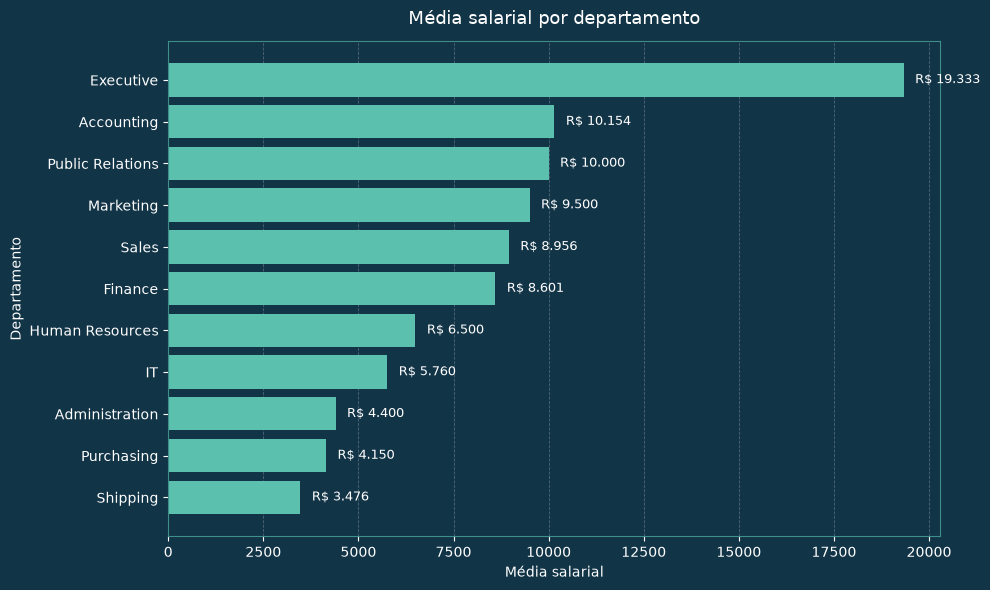

In [14]:
# Visualização da média salarial por departamento

fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de barras horizontais
barras = ax.barh(
    resumo_departamento.index, resumo_departamento["media_salarial"], color="#5CC0AE"
)

# Fundo do gráfico
fig.patch.set_facecolor("#123447")
ax.set_facecolor("#123447")

# Títulos e eixos
ax.set_title("Média salarial por departamento", color="white", fontsize=13, pad=12)

ax.set_xlabel("Média salarial", color="white")

ax.set_ylabel("Departamento", color="white")

# Cor dos textos dos eixos
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# Grade discreta
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.25, color="white")

ax.set_axisbelow(True)

# Bordas do gráfico
for spine in ax.spines.values():
    spine.set_color("#3E8F8A")

# Valores nas barras
for barra in barras:
    valor = barra.get_width()

    ax.text(
        valor + 300,
        barra.get_y() + barra.get_height() / 2,
        f"R$ {valor:,.0f}".replace(",", "."),
        va="center",
        fontsize=9,
        color="white",
    )

# Coloca o maior salário no topo
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Leitura

As médias salariais apresentam diferenças entre os departamentos, com destaque para Executive. A quantidade de funcionários por departamento deve ser considerada na interpretação dessas médias.

### Visualização- Distribuição dos Salários

O histograma permite observar como os salários estão distribuídos e identificar a concentração dos valores ao longo da faixa salarial.

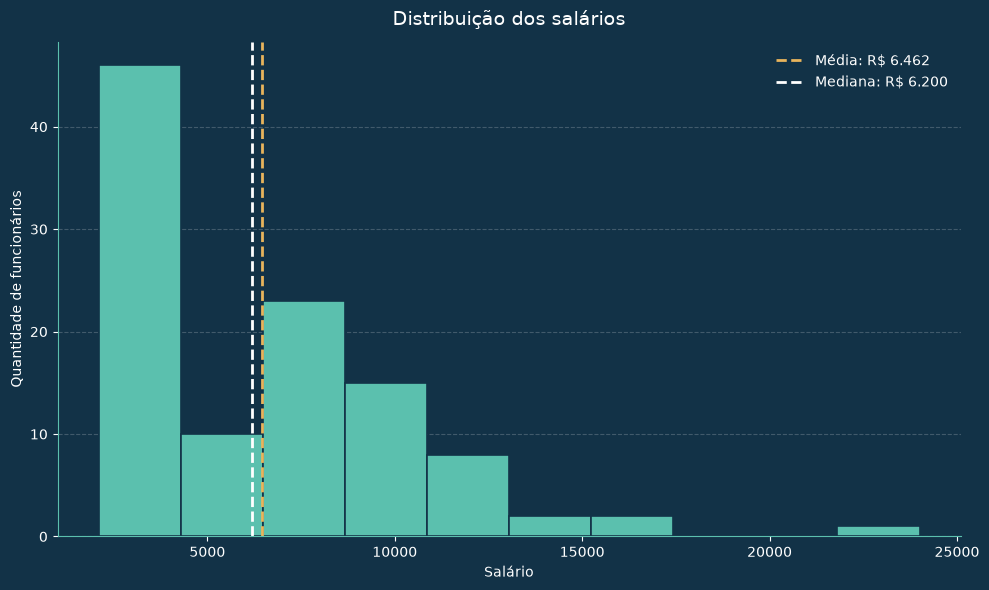

In [15]:
# Distribuição dos salários

plt.figure(figsize=(10, 6), facecolor="#123247")

ax = plt.gca()
ax.set_facecolor("#123247")

# Histograma
ax.hist(
    df_query1["SALARY"], bins=10, color="#5BC0AE", edgecolor="#123247", linewidth=1.2
)

# Média e mediana
media = df_query1["SALARY"].mean()
mediana = df_query1["SALARY"].median()

ax.axvline(
    media,
    color="#E8B45C",
    linestyle="--",
    linewidth=2,
    label=f"Média: R$ {media:,.0f}".replace(",", "."),
)

ax.axvline(
    mediana,
    color="#FFFFFF",
    linestyle="--",
    linewidth=2,
    label=f"Mediana: R$ {mediana:,.0f}".replace(",", "."),
)

# Títulos e eixos
ax.set_title("Distribuição dos salários", color="white", fontsize=14, pad=12)

ax.set_xlabel("Salário", color="white")

ax.set_ylabel("Quantidade de funcionários", color="white")

# Eixos
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# Grade discreta
ax.grid(axis="y", linestyle="--", alpha=0.20, color="white")

ax.set_axisbelow(True)

# Bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#5BC0AE")
ax.spines["bottom"].set_color("#5BC0AE")

# Legenda
ax.legend(frameon=False, labelcolor="white")

plt.tight_layout()
plt.show()

### Leitura 

A maior concentração de salários está nas faixas inferiores, enquanto poucos valores mais altos se estendem até R$ 24.000, indicando uma distribuição assimétrica à direita.

### Média salarial por cargo

A média salarial permite observar como os valores se distribuem entre os diferentes cargos da base.

In [16]:
media_cargo = (
    df_query1.groupby("JOB_TITLE")["SALARY"].mean().sort_values(ascending=False)
)

display(media_cargo)

JOB_TITLE
President                          24000.0
Administration Vice President      17000.0
Marketing Manager                  13000.0
Sales Manager                      12200.0
Finance Manager                    12008.0
Accounting Manager                 12008.0
Purchasing Manager                 11000.0
Public Relations Representative    10000.0
Sales Representative                8350.0
Public Accountant                   8300.0
Accountant                          7920.0
Stock Manager                       7280.0
Human Resources Representative      6500.0
Marketing Representative            6000.0
Programmer                          5760.0
Administration Assistant            4400.0
Shipping Clerk                      3215.0
Stock Clerk                         2785.0
Purchasing Clerk                    2780.0
Name: SALARY, dtype: float64

### Quantidade de funcionários por cargo

A quantidade de funcionários por cargo complementa a análise das médias salariais.

In [17]:
quantidade_cargo = df_query1["JOB_TITLE"].value_counts()

display(quantidade_cargo)

JOB_TITLE
Sales Representative               30
Stock Clerk                        20
Shipping Clerk                     20
Purchasing Clerk                    5
Stock Manager                       5
Programmer                          5
Sales Manager                       5
Accountant                          5
Administration Vice President       2
Administration Assistant            1
Marketing Manager                   1
Marketing Representative            1
Purchasing Manager                  1
Human Resources Representative      1
Public Relations Representative     1
President                           1
Finance Manager                     1
Accounting Manager                  1
Public Accountant                   1
Name: count, dtype: int64

### Visualização- Média Salarial por Cargo

O gráfico mostra a diferença entre as médias salariais dos cargos e a concentração de funcionários em algumas funções.

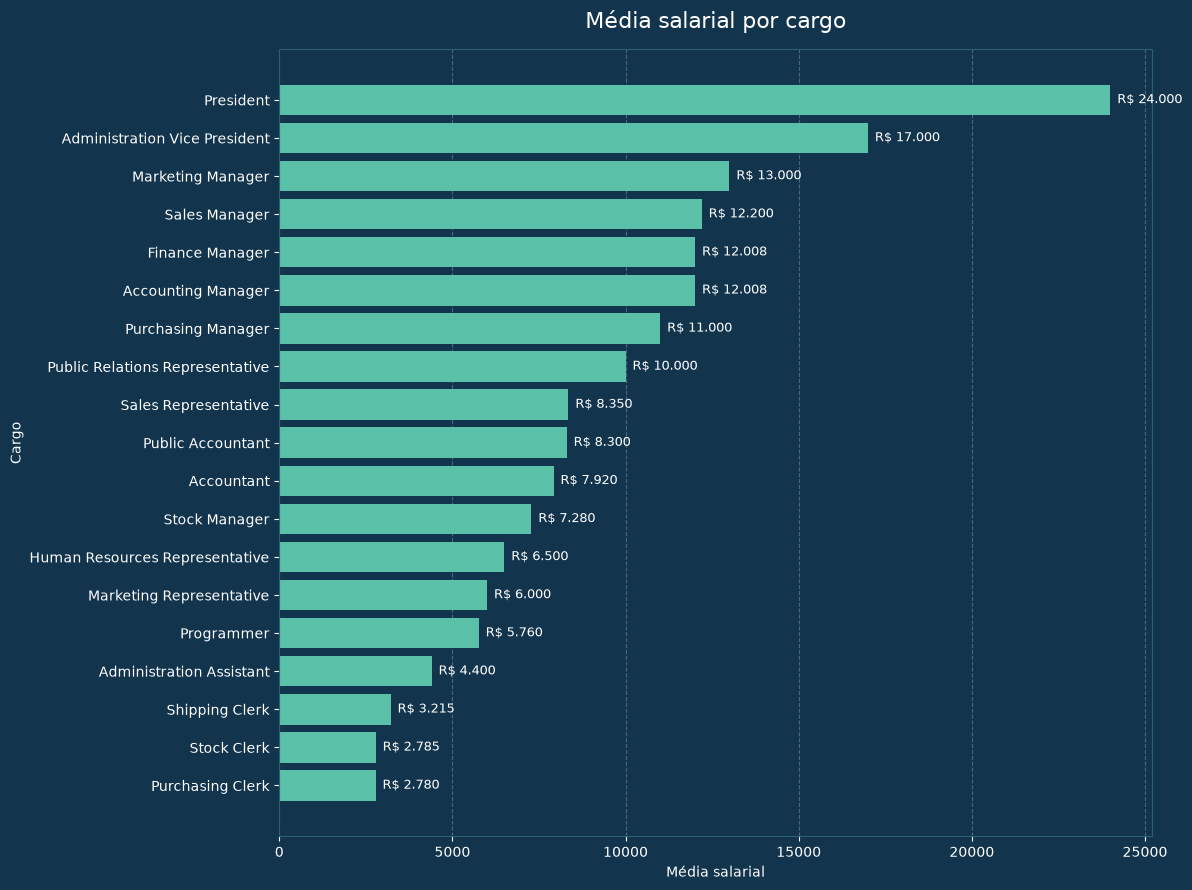

In [18]:
# Média salarial por cargo
media_cargo = (
    df_query1.groupby("JOB_TITLE")["SALARY"].mean().sort_values(ascending=True)
)

# Configuração da figura
fig, ax = plt.subplots(figsize=(12, 9))

fig.patch.set_facecolor("#12344D")
ax.set_facecolor("#12344D")

# Barras
bars = ax.barh(media_cargo.index, media_cargo.values, color="#5BC0A8")

# Título e eixos
ax.set_title("Média salarial por cargo", fontsize=16, color="white", pad=15)

ax.set_xlabel("Média salarial", color="white")

ax.set_ylabel("Cargo", color="white")

# Eixos
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# Grade
ax.grid(axis="x", linestyle="--", alpha=0.25, color="white")

ax.set_axisbelow(True)

# Valores nas barras
for bar, valor in zip(bars, media_cargo.values):
    ax.text(
        valor + 200,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {valor:,.0f}".replace(",", "."),
        va="center",
        fontsize=9,
        color="white",
    )

# Remover bordas desnecessárias
for spine in ax.spines.values():
    spine.set_color("#2A6170")

plt.tight_layout()
plt.show()

### Leitura

A média salarial apresenta diferenças entre os cargos, com valores mais elevados nas funções de gestão e no cargo de President. Como alguns cargos possuem apenas um funcionário, essas médias devem ser interpretadas considerando também a quantidade de registros de cada cargo.

## Síntese da análise — Query 1

A análise dos salários por departamento e cargo evidencia diferenças entre os grupos. A distribuição dos salários concentra-se nas faixas inferiores, enquanto poucos valores mais elevados ampliam a média. As comparações por departamento e cargo também devem considerar a quantidade de funcionários em cada grupo.

A partir dessa leitura dos salários, a análise avança para a dimensão geográfica da base.

# QUERY 2 — FUNCIONÁRIOS E SALÁRIOS POR REGIÃO

## Contexto geográfico dos dados

In [19]:
print("CONTEXTO GEOGRÁFICO DOS DADOS  — QUERY 2")

print("Shape:", df_query2.shape)

print("\nCOLUNAS:")
print(df_query2.columns.tolist())

print("\nTIPOS:")
print(df_query2.dtypes)

print("\nPRIMEIROS REGISTROS:")
display(df_query2.head())

print("\nÚLTIMOS REGISTROS:")
display(df_query2.tail())

CONTEXTO GEOGRÁFICO DOS DADOS  — QUERY 2
Shape: (107, 9)

COLUNAS:
['EMPLOYEE_ID', 'FIRST_NAME', 'LAST_NAME', 'SALARY', 'DEPARTMENT_NAME', 'JOB_TITLE', 'CITY', 'COUNTRY_NAME', 'REGION_NAME']

TIPOS:
EMPLOYEE_ID        int64
FIRST_NAME           str
LAST_NAME            str
SALARY             int64
DEPARTMENT_NAME      str
JOB_TITLE            str
CITY                 str
COUNTRY_NAME         str
REGION_NAME          str
dtype: object

PRIMEIROS REGISTROS:


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE,CITY,COUNTRY_NAME,REGION_NAME
0,103,Alexander,James,9000,IT,Programmer,Southlake,United States of America,Americas
1,104,Bruce,Miller,6000,IT,Programmer,Southlake,United States of America,Americas
2,105,David,Williams,4800,IT,Programmer,Southlake,United States of America,Americas
3,106,Valli,Jackson,4800,IT,Programmer,Southlake,United States of America,Americas
4,107,Diana,Nguyen,4200,IT,Programmer,Southlake,United States of America,Americas



ÚLTIMOS REGISTROS:


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE,CITY,COUNTRY_NAME,REGION_NAME
102,176,Jonathon,Taylor,8600,Sales,Sales Representative,Oxford,United Kingdom of Great Britain and Northern I...,Europe
103,177,Jack,Livingston,8400,Sales,Sales Representative,Oxford,United Kingdom of Great Britain and Northern I...,Europe
104,179,Charles,Johnson,6200,Sales,Sales Representative,Oxford,United Kingdom of Great Britain and Northern I...,Europe
105,204,Hermann,Brown,10000,Public Relations,Public Relations Representative,Munich,Germany,Europe
106,178,Kimberely,Grant,7000,NaN,Sales Representative,NaN,NaN,NaN


### Qualidade dos dados

In [20]:
print("QUALIDADE DOS DADOS — QUERY 2")

print("\nVALORES NULOS:")
print(df_query2.isnull().sum())

print("\nREGISTROS DUPLICADOS:")
print(df_query2.duplicated().sum())

print("\nESTATÍSTICA DESCRITIVA:")
display(df_query2.describe(include="all"))

QUALIDADE DOS DADOS — QUERY 2

VALORES NULOS:
EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
SALARY             0
DEPARTMENT_NAME    1
JOB_TITLE          0
CITY               1
COUNTRY_NAME       1
REGION_NAME        1
dtype: int64

REGISTROS DUPLICADOS:
0

ESTATÍSTICA DESCRITIVA:


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE,CITY,COUNTRY_NAME,REGION_NAME
count,107.000000,107,107,107.000000,106,107,106,106,106
unique,NaN,92,102,NaN,11,19,7,4,2
top,NaN,David,Taylor,NaN,Shipping,Sales Representative,South San Francisco,United States of America,Americas
freq,NaN,3,2,NaN,45,30,45,68,70
mean,153.000000,NaN,NaN,6461.831776,NaN,NaN,NaN,NaN,NaN
std,31.032241,NaN,NaN,3909.579731,NaN,NaN,NaN,NaN,NaN
min,100.000000,NaN,NaN,2100.000000,NaN,NaN,NaN,NaN,NaN
25%,126.500000,NaN,NaN,3100.000000,NaN,NaN,NaN,NaN,NaN
50%,153.000000,NaN,NaN,6200.000000,NaN,NaN,NaN,NaN,NaN
75%,179.500000,NaN,NaN,8900.000000,NaN,NaN,NaN,NaN,NaN


In [21]:
print("REGISTRO COM INFORMAÇÃO GEOGRÁFICA AUSENTE:")

display(df_query2[df_query2["REGION_NAME"].isna()])

REGISTRO COM INFORMAÇÃO GEOGRÁFICA AUSENTE:


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE,CITY,COUNTRY_NAME,REGION_NAME
106,178,Kimberely,Grant,7000,NaN,Sales Representative,NaN,NaN,NaN


### Distribuição dos funcionários por região

A distribuição regional considera apenas os registros com informação geográfica disponível. A base possui 107 funcionários, sendo 70 nas Américas e 36 na Europa. Um registro não possui informação de região e será considerado separadamente nas análises que dependem dessa variável.

In [22]:
print("FUNCIONÁRIOS POR REGIÃO")

funcionarios_regiao = df_query2["REGION_NAME"].value_counts(dropna=False)

display(funcionarios_regiao)

FUNCIONÁRIOS POR REGIÃO


REGION_NAME
Americas    70
Europe      36
NaN          1
Name: count, dtype: int64

### Salário por Região

In [23]:
print("SALÁRIO POR REGIÃO")

salario_regiao = (
    df_query2.groupby("REGION_NAME", dropna=False)["SALARY"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(salario_regiao)

SALÁRIO POR REGIÃO


,count,mean,median,min,max
REGION_NAME,,,,,
Europe,36,8916.666667,8900.0,6100,14000
NaN,1,7000.000000,7000.0,7000,7000
Americas,70,5191.657143,3300.0,2100,24000


### Visualização — Distribuição dos salários por região

O boxplot permite comparar a distribuição dos salários entre as regiões, observando a mediana, a dispersão dos valores e possíveis valores extremos.

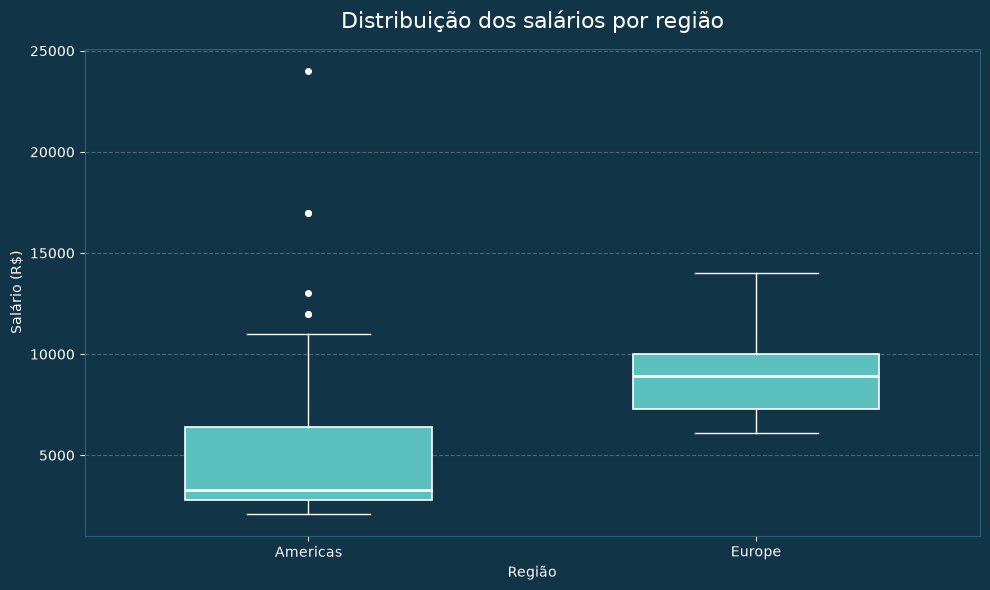

In [24]:
# Remove o registro sem região apenas para a visualização
df_boxplot = df_query2.dropna(subset=["REGION_NAME"])

# Ordem das regiões pela quantidade de funcionários
ordem_regioes = df_boxplot["REGION_NAME"].value_counts().index

# Dados para o boxplot
dados_regiao = [
    df_boxplot.loc[df_boxplot["REGION_NAME"] == regiao, "SALARY"]
    for regiao in ordem_regioes
]

# Figura
fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot
box = ax.boxplot(dados_regiao, patch_artist=True, widths=0.55, showfliers=True)

# Nomes das regiões
ax.set_xticks(range(1, len(ordem_regioes) + 1))
ax.set_xticklabels(ordem_regioes)

# Cores das caixas
for patch in box["boxes"]:
    patch.set_facecolor("#5BC0BE")
    patch.set_edgecolor("#FFFFFF")
    patch.set_linewidth(1.2)

# Medianas
for median in box["medians"]:
    median.set_color("#FFFFFF")
    median.set_linewidth(2)

# Bigodes
for whisker in box["whiskers"]:
    whisker.set_color("#FFFFFF")

# Limites dos bigodes
for cap in box["caps"]:
    cap.set_color("#FFFFFF")

# Valores extremos
for flier in box["fliers"]:
    flier.set_marker("o")
    flier.set_markerfacecolor("#FFFFFF")
    flier.set_markeredgecolor("#FFFFFF")
    flier.set_markersize(4)

# Fundo — padrão dos gráficos anteriores
fig.patch.set_facecolor("#123447")
ax.set_facecolor("#123447")

# Título
ax.set_title("Distribuição dos salários por região", fontsize=16, color="white", pad=15)

# Eixos
ax.set_xlabel("Região", color="white")
ax.set_ylabel("Salário (R$)", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# Grade
ax.grid(axis="y", linestyle="--", alpha=0.25, color="white")

# Bordas
for spine in ax.spines.values():
    spine.set_color("#2A6178")

plt.tight_layout()
plt.show()

### Leitura

O boxplot evidencia diferenças na distribuição salarial entre as regiões. Na Europa, os salários apresentam maior concentração em torno da mediana, enquanto nas Américas a distribuição é mais ampla e apresenta maior dispersão, com valores extremos superiores. Esse comportamento é consistente com as estatísticas descritivas observadas anteriormente, especialmente pela presença de salários elevados na região das Américas. A comparação é descritiva e não permite atribuir causalidade à localização.

## Síntese da análise — Query 2

A distribuição regional mostra que a maior parte dos funcionários está concentrada nas Américas, com 70 dos 107 registros, enquanto a Europa reúne 36 funcionários. Um registro não possui informações de departamento, cidade, país ou região e, por isso, foi mantido na base, mas não incluído nas comparações entre regiões.

 Na dimensão salarial, a Europa apresenta média de R$ 8.916,67 e mediana de R$ 8.900, enquanto as Américas apresentam média de R$ 5.191,67 e mediana de R$ 3.300.
 
 A análise permite identificar diferenças na distribuição de funcionários e salários entre as regiões. Essas diferenças são descritivas e não permitem estabelecer uma relação causal entre localização e remuneração.

# Conclusão Geral

A análise mostrou diferenças salariais entre cargos, departamentos e regiões, além de diferentes níveis de concentração e dispersão dos salários. A comparação entre média e mediana também mostrou que a média, isoladamente, não é suficiente para compreender a distribuição dos valores, principalmente diante da presença de salários elevados.

## Insight

O principal insight está na própria distribuição dos salários: ela não é uniforme entre os grupos analisados. Quando cargo, departamento, região, quantidade de funcionários, média, mediana e distribuição são observados em conjunto, surgem padrões que não aparecem quando olhamos apenas para a média salarial.

## Impacto

Os dados ajudam a localizar diferenças e padrões que podem ser investigados antes de uma decisão sobre remuneração ou estrutura organizacional.

Nesse sentido, a análise contribui para fazer perguntas melhores, direcionar novas investigações e dar mais contexto às decisões de RH.

## Limitação

Os resultados são descritivos e representam apenas os dados disponíveis na base analisada. As diferenças observadas não permitem estabelecer relações de causa e efeito. Alguns grupos possuem poucos funcionários e existe um registro com informações geográficas ausentes, fatores que devem ser considerados na interpretação dos resultados.